In [ ]:
from pathlib import Path
import json
from collections import defaultdict
from typing import List, Dict, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt


def plot_learning_curves(
    dataset: str,
    data_poisoning_method: str,
    features_percentage: float,
    poisoning_percentage: float,
    model: str,
    frogdq_modes: list[str],
    plot_y: str,
    print_test_summary: bool = True,
    ci_z: float = 1.96,  # 95% normal-approx CI by default
) -> None:
    """
    Plot aggregated validation learning curves across FrogDQ modes and print
    per-mode test metric summaries (mean, std, and 95% CI by default).

    Parameters
    ----------
    dataset : str
        Dataset name used in experiments.
    data_poisoning_method : str
        Poisoning method (matches key "poisoning_method").
    features_percentage : float
        Percentage of features poisoned.
    poisoning_percentage : float
        Percentage of instances poisoned.
    model : str
        Model architecture (matches key "model_type").
    frogdq_modes : list of str
        List of FrogDQ modes to include (matches key "frogdq_mode").
    plot_y : {"loss", "accuracy", "balanced_accuracy", "f1", "auc"}
        Which validation metric to plot (validation curves).
    print_test_summary : bool, default True
        If True, prints per-frogdq_mode summary stats for test metrics.
    ci_z : float, default 1.96
        Z value for two-sided normal-approx confidence interval (1.96 ~ 95% CI).
        Change to 2.576 for ~99% CI, etc.
    """
    # Resolve experiment results path (repo root)
    results_path = Path("results/Mimic/experiment_results.json")

    if not results_path.exists():
        print(f"File not found: {results_path}")
        return

    # Read JSON with robust fallbacks
    try:
        text = results_path.read_text(encoding="utf-8")
    except Exception as e:
        print(f"Could not read results file: {e}")
        return

    if not text.strip():
        print("Results file is empty.")
        return

    try:
        payload = json.loads(text)
    except json.JSONDecodeError as e:
        print(f"Invalid JSON: {e}")
        return

    # Support two shapes: {"experiments": [...]} or a raw list [...]
    if isinstance(payload, dict) and "experiments" in payload and isinstance(payload["experiments"], list):
        experiments = payload["experiments"]
    elif isinstance(payload, list):
        experiments = payload
    else:
        print('Unrecognized results structure. Expecting {"experiments": [...]} or a list.')
        return

    # Map requested metric to history key (for validation curves)
    metric_map = {
        "loss": "val_loss",
        "accuracy": "val_acc",
        "balanced_accuracy": "val_bal_acc",
        "f1": "val_f1",
        "auc": "val_auc",
    }
    if plot_y not in metric_map:
        print(f"Unsupported plot_y '{plot_y}'. Choose one of {list(metric_map)}")
        return
    history_key = metric_map[plot_y]

    # Filter experiments by parameters
    def _match(exp: Dict) -> bool:
        return (
            exp.get("dataset") == dataset
            and exp.get("poisoning_method") == data_poisoning_method
            and float(exp.get("features_percentage")) == float(features_percentage)
            and float(exp.get("poisoning_percentage")) == float(poisoning_percentage)
            and exp.get("model_type") == model
        )

    filtered: List[Dict] = [exp for exp in experiments if _match(exp)]

    if not filtered:
        print("No experiments matched the provided filters.")
        return

    # ---- Helper functions ----------------------------------------------------
    def _ensure_float_list(seq) -> Optional[List[float]]:
        if not isinstance(seq, list) or len(seq) == 0:
            return None
        out = []
        for x in seq:
            if x is None:
                out.append(np.nan)
            else:
                try:
                    out.append(float(x))
                except (TypeError, ValueError):
                    out.append(np.nan)
        return out

    def _last_finite(value_or_list) -> Optional[float]:
        """
        Accepts either a scalar or a list. If list, returns the last finite value.
        If scalar, returns it if finite. Otherwise None.
        """
        if isinstance(value_or_list, list):
            arr = _ensure_float_list(value_or_list)
            if not arr:
                return None
            # walk backward to find last finite
            for v in reversed(arr):
                if np.isfinite(v):
                    return float(v)
            return None
        # scalar:
        try:
            v = float(value_or_list)
        except (TypeError, ValueError):
            return None
        return float(v) if np.isfinite(v) else None

    def _mean_std_ci(vals: List[float], z: float) -> Tuple[Optional[float], Optional[float], Optional[Tuple[float, float]]]:
        """
        Returns (mean, std, (lo, hi)) using population unbiased std (ddof=1) when n>1.
        CI uses normal-approx: mean ± z * (std/sqrt(n)) if n>1.
        """
        clean = [float(v) for v in vals if v is not None and np.isfinite(v)]
        n = len(clean)
        if n == 0:
            return None, None, None
        m = float(np.mean(clean))
        if n == 1:
            return m, None, None
        sd = float(np.std(clean, ddof=1))
        se = sd / np.sqrt(n)
        lo, hi = m - z * se, m + z * se
        return m, sd, (lo, hi)

    # ---- Aggregate validation histories (for plotting) -----------------------
    by_mode_val_hist: Dict[str, List[List[float]]] = defaultdict(list)
    for exp in filtered:
        mode = exp.get("frogdq_mode", "unknown")
        if mode in frogdq_modes:
            hist = (exp.get("history") or {})
            seq = hist.get(history_key)
            seq = _ensure_float_list(seq)
            if seq:
                by_mode_val_hist[mode].append(seq)

    # ---- Aggregate test metrics (for printing) -------------------------------
    test_metric_keys = [
        "test_loss",
        "test_acc",
        "test_bal_acc",
        "test_f1",
        "test_auc",
    ]
    # per-mode -> per-metric -> list of scalars
    test_values_by_mode: Dict[str, Dict[str, List[float]]] = defaultdict(lambda: defaultdict(list))

    for exp in filtered:
        mode = exp.get("frogdq_mode", "unknown")
        if mode in frogdq_modes:
            hist = (exp.get("history") or {})
            for k in test_metric_keys:
                v = hist.get(k)
                final_v = _last_finite(v)
                if final_v is not None and np.isfinite(final_v):
                    test_values_by_mode[mode][k].append(final_v)

    # ---- Print per-mode summaries -------------------------------------------
    if print_test_summary:
        # Header
        print("\n=== Test Metric Summary by frogdq_mode ===")
        print(f"(dataset={dataset}, poison={data_poisoning_method}, feat%={features_percentage}, "
              f"pois%={poisoning_percentage}, model={model})")
        # Column widths
        mode_w = max(11, max((len(str(m)) for m in test_values_by_mode.keys()), default=11))
        col_names = ["n", "test_loss", "test_acc", "test_bal_acc", "test_f1", "test_auc"]
        def _fmt_cell(stats):
            m, sd, ci = stats
            if m is None:
                return "—"
            if sd is None or ci is None:
                return f"{m:.4f} (n=1)"
            lo, hi = ci
            return f"{m:.4f} ± {sd:.4f}  [{lo:.4f}, {hi:.4f}]"

        header = f"{'frogdq_mode'.ljust(mode_w)}  " + "  ".join(name.center(36) for name in col_names)
        print(header)
        print("-" * len(header))

        # Rows
        for mode in sorted(test_values_by_mode.keys()):
            row = [mode.ljust(mode_w)]
            # n per mode (could vary by metric if missing; show max n across metrics)
            n_mode = max((len(vs) for vs in test_values_by_mode[mode].values()), default=0)
            row.append(str(n_mode).center(36))
            for metric in test_metric_keys:
                stats = _mean_std_ci(test_values_by_mode[mode].get(metric, []), ci_z)
                row.append(_fmt_cell(stats).center(36))
            print("  ".join(row))

        # Note about CI method
        print("\nNote: CI uses normal approximation (mean ± z * SE) with z="
              f"{ci_z}. For small n, consider a t-interval.\n")

    # ---- Plot validation curves ---------------------------------------------
    if not by_mode_val_hist:
        print(f"No '{history_key}' sequences found for the matched experiments.")
        return

    def elementwise_mean_ci(sequences: List[List[float]], z: float = 1.96):
        """
        Compute elementwise mean and CI (mean ± z * SE) for a list of equal or variable-length sequences.
        Returns: mean_curve, lower_bound, upper_bound
        """
        max_len = max(len(s) for s in sequences)
        means, lowers, uppers = [], [], []
        for i in range(max_len):
            vals = [s[i] for s in sequences if i < len(s) and np.isfinite(s[i])]
            if len(vals) == 0:
                # repeat last known values if missing
                means.append(means[-1] if means else np.nan)
                lowers.append(lowers[-1] if lowers else np.nan)
                uppers.append(uppers[-1] if uppers else np.nan)
            else:
                m = float(np.mean(vals))
                sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
                se = sd / np.sqrt(len(vals)) if len(vals) > 1 else 0.0
                lo, hi = m - z * se, m + z * se
                means.append(m)
                lowers.append(lo)
                uppers.append(hi)
        return means, lowers, uppers

    plt.figure(figsize=(10, 6))

    # Colorblind-friendly Okabe–Ito palette
    colors = [
        "#E69F00", "#56B4E9", "#009E73",
        "#F0E442", "#0072B2", "#D55E00",
        "#CC79A7", "#999999"
    ]
    linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2))]
    markers = ["o", "s", "D", "^", "v", ">", "<", "x", "P", "*"]

    for i, (mode, seqs) in enumerate(sorted(by_mode_val_hist.items())):
        mean_curve, lower, upper = elementwise_mean_ci(seqs, z=ci_z)
        epochs = range(len(mean_curve))
        color = colors[i % len(colors)]
        style = linestyles[i % len(linestyles)]
        marker = markers[i % len(markers)]

        # Main curve
        plt.plot(
            epochs,
            mean_curve,
            label=f"{mode} (n={len(seqs)})",
            color=color,
            linestyle=style,
            linewidth=2.2,
            marker=marker,
            markersize=5,
            markevery=max(1, len(mean_curve) // 12),
        )

        # Confidence band
        plt.fill_between(
            epochs,
            lower,
            upper,
            color=color,
            alpha=0.2,
            linewidth=0,
        )

    plt.title(
        f"Validation {plot_y} — dataset={dataset}, poison={data_poisoning_method}, "
        f"feat%={features_percentage}, pois%={poisoning_percentage}, model={model}"
    )
    plt.xlabel("Epoch")
    plt.ylabel(plot_y.replace("_", " ").title())
    plt.grid(True, alpha=0.3)

    # Better legend
    legend = plt.legend(
        title="FrogDQ Mode",
        loc="best",
        frameon=True,
        framealpha=0.85,
        fancybox=True,
        fontsize=9,
        title_fontsize=10,
    )
    legend.get_frame().set_facecolor("#f9f9f9")

    plt.tight_layout()

    '''# --- Titles and labels ---
    title_text = (
        f"{dataset}_{data_poisoning_method}_{features_percentage}_"
        f"{poisoning_percentage}_{model}"
    )

    # --- Save figure ---
    save_dir = Path(f"{dataset}_results")
    save_dir.mkdir(parents=True, exist_ok=True)
    save_path = save_dir / f"{title_text}.png"

    plt.savefig(save_path, dpi=300, bbox_inches="tight")'''
    plt.show()

    '''print(f"\n✅ Plot saved to: {save_path}\n")'''




=== Test Metric Summary by frogdq_mode ===
(dataset=mimic, poison=clean, feat%=0.2, pois%=0.2, model=mlp)
frogdq_mode                   n                                 test_loss                              test_acc                            test_bal_acc                            test_f1                               test_auc              
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
none                          1                                0.5432 (n=1)                          0.7985 (n=1)                          0.8010 (n=1)                          0.8030 (n=1)                          0.9442 (n=1)            

Note: CI uses normal approximation (mean ± z * SE) with z=1.96. For small n, consider a t-interval.



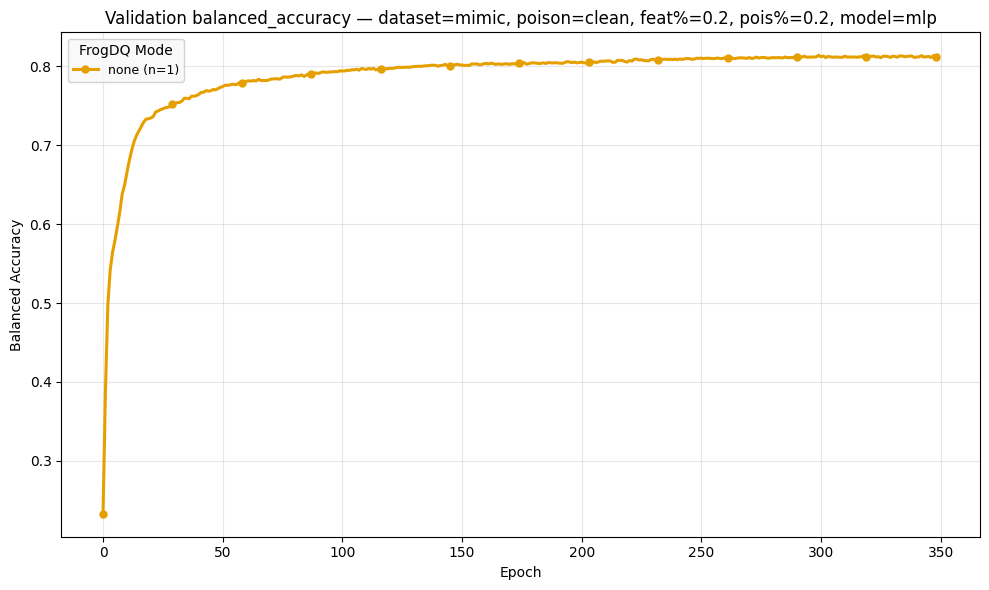

In [4]:
plot_learning_curves(
    dataset='mimic',
    data_poisoning_method='clean',
    features_percentage=0.2,
    poisoning_percentage=0.2, 
    model="mlp",
    frogdq_modes=["none"],
    plot_y="balanced_accuracy",
)

In [ ]:
def plot_mean_frog_gate_variation(
    dataset: str,
    data_poisoning_method: str,
    features_percentage: float,
    poisoning_percentage: float,
    model: str,
    plot_y: str,
    frogdq_mode: str,
) -> None:
    """
    Plot the mean gate trajectory per feature across epochs for a specific FrogDQ mode.
    The signature mirrors `plot_learning_curves`; `plot_y` is unused and kept for
    compatibility with previous call sites.
    """
    _ = plot_y  # Preserve signature compatibility
    results_path = Path("experiment_results.json")

    if not results_path.exists():
        print(f"File not found: {results_path}")
        return

    try:
        text = results_path.read_text(encoding="utf-8")
    except Exception as e:
        print(f"Could not read results file: {e}")
        return

    if not text.strip():
        print("Results file is empty.")
        return

    try:
        payload = json.loads(text)
    except json.JSONDecodeError as e:
        print(f"Invalid JSON: {e}")
        return

    if isinstance(payload, dict) and "experiments" in payload and isinstance(payload["experiments"], list):
        experiments = payload["experiments"]
    elif isinstance(payload, list):
        experiments = payload
    else:
        print('Unrecognized results structure. Expecting {"experiments": [...]} or a list.')
        return

    def _match(exp: Dict) -> bool:
        return (
            exp.get("dataset") == dataset
            and exp.get("poisoning_method") == data_poisoning_method
            and float(exp.get("features_percentage", float('nan'))) == float(features_percentage)
            and float(exp.get("poisoning_percentage", float('nan'))) == float(poisoning_percentage)
            and exp.get("model_type") == model
            and exp.get("frogdq_mode") == frogdq_mode
        )

    filtered = [exp for exp in experiments if _match(exp)]

    if not filtered:
        print("No experiments matched the provided filters.")
        return

    gate_matrices = []
    gate_dim = None

    for exp in filtered:
        gates_seq = exp.get("history", {}).get("frog_gates")
        if not gates_seq:
            continue

        gate_vecs = []
        valid = True
        for g in gates_seq:
            if g is None:
                valid = False
                break
            try:
                arr = np.asarray(g, dtype=float)
            except (TypeError, ValueError):
                valid = False
                break
            if arr.ndim != 1:
                valid = False
                break
            gate_vecs.append(arr)

        if not valid or len(gate_vecs) == 0:
            continue

        dims = {vec.shape[0] for vec in gate_vecs}
        if len(dims) != 1:
            continue

        current_dim = gate_vecs[0].shape[0]
        if gate_dim is None:
            gate_dim = current_dim
        elif gate_dim != current_dim:
            print("Skipping experiment with mismatched gate dimension.")
            continue

        gate_matrix = np.vstack(gate_vecs)  # (epochs, gates)
        gate_matrices.append(gate_matrix)

    if not gate_matrices:
        print("No FrogDQ gate trajectories with sufficient data were found for the provided filters.")
        return

    min_epochs = min(mat.shape[0] for mat in gate_matrices)
    trimmed = [mat[:min_epochs] for mat in gate_matrices]
    stacked = np.stack(trimmed, axis=0)  # (runs, epochs, gates)
    mean_trajectories = stacked.mean(axis=0)  # (epochs, gates)

    epochs = np.arange(1, min_epochs + 1)
    plt.figure(figsize=(11, 6))

    n_gates = mean_trajectories.shape[1]
    cmap = plt.cm.get_cmap('tab20', n_gates)
    for gate_idx in range(n_gates):
        plt.plot(
            epochs,
            mean_trajectories[:, gate_idx],
            color=cmap(gate_idx),
            linewidth=2.0,
            label=f"Gate {gate_idx}",
        )

    plt.title(
        f"Mean Frog Gate Value per Epoch — dataset={dataset}, poison={data_poisoning_method}, "
        f"feat%={features_percentage}, pois%={poisoning_percentage}, model={model}, mode={frogdq_mode}"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Mean gate value")
    plt.grid(True, alpha=0.3)

    legend = plt.legend(
        title="Gate index",
        loc="upper right",
        frameon=True,
        framealpha=0.85,
        fancybox=True,
        fontsize=8,
        title_fontsize=9,
    )
    legend.get_frame().set_facecolor("#f9f9f9")

    plt.tight_layout()
    plt.show()

    print(
        f"Aggregated {len(gate_matrices)} matching runs. Epochs aligned to the first {min_epochs} entries across runs."
    )
